# Препроцессинг датасета «Успеваемость учащихся по математике»

**Описание метода:** Препроцессинг (предварительная обработка данных) — обязательный этап перед обучением любой модели машинного обучения. Включает чистку данных (удаление дубликатов, обработку пропусков и выбросов), кодирование категориальных признаков, анализ корреляций с помощью тепловой матрицы для удаления избыточных признаков, а также отбор наиболее информативных признаков с использованием алгоритма Gain Ratio — метрики из алгоритма построения деревьев решений C4.5, которая оценивает информативность признака относительно целевой переменной с поправкой на количество его уникальных значений.

## 1. Используемые библиотеки

In [1]:
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

print('Все библиотеки успешно импортированы!')

Все библиотеки успешно импортированы!


## 2. Загрузка и описание датасета

**О датасете:** Данные собраны в двух португальских средних школах. Содержат демографические, социальные и школьные характеристики 395 учащихся, а также их оценки по математике за три периода (G1, G2, G3). Датасет используется для предсказания итоговой оценки (G3).

**Целевая переменная:** `pass` — бинарный признак (1 = сдал: G3 ≥ 10, 0 = не сдал: G3 < 10).

**Всего признаков:** 33 (числовые и категориальные).

In [2]:
# Загружаем файл (выберите student-mat.csv)
uploaded = files.upload()
df = pd.read_csv('dataset.csv', sep=';')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df.head())

Saving dataset.csv to dataset.csv
Размер датасета: 395 строк, 33 столбцов

--- Первые 5 строк ---


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
print('--- Типы данных и наличие значений ---')
print(df.info())
print('\n--- Базовая статистика числовых признаков ---')
display(df.describe())

--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery    

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 3. Предварительная обработка датасета (Препроцессинг)

### 3.1 Проверка пропущенных значений и дубликатов

In [4]:
print('=== Пропущенные значения по каждому признаку ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'Пропущенных значений не обнаружено.')

print(f'\n=== Дубликаты ===')
print(f'Количество дублирующихся строк: {df.duplicated().sum()}')
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print('Дубликаты удалены.')

print(f'\nИтоговый размер датасета после проверки: {df.shape}')

=== Пропущенные значения по каждому признаку ===
Пропущенных значений не обнаружено.

=== Дубликаты ===
Количество дублирующихся строк: 0

Итоговый размер датасета после проверки: (395, 33)


**Вывод:** В датасете отсутствуют пропущенные значения — данные были собраны с помощью анкетирования и школьных отчётов, что обеспечило полноту записей. Дубликаты также отсутствуют. Восстановление данных не требуется.

### 3.2 Создание целевой переменной (бинаризация G3)

Распределение целевой переменной (pass):
pass
1    265
0    130
Name: count, dtype: int64

Доля сдавших: 67.1%


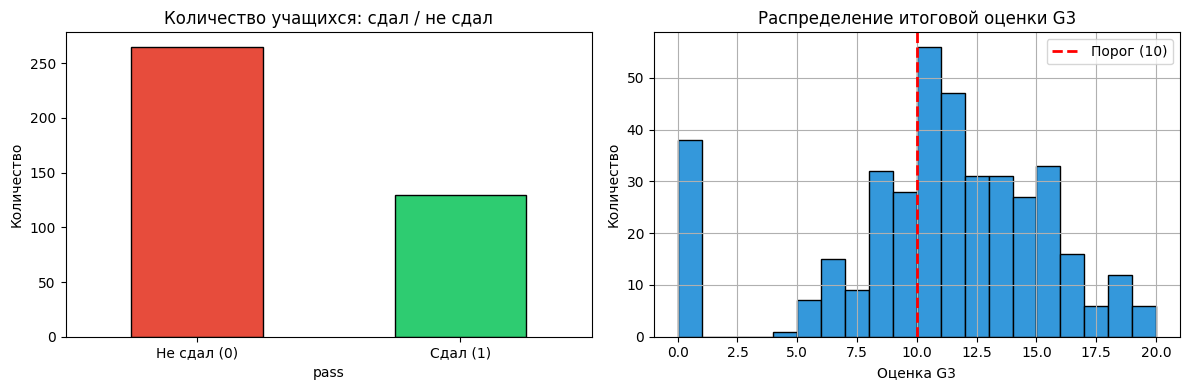

In [5]:
# Создаём бинарную целевую переменную: сдал (1) / не сдал (0)
# Порог 10 — стандартная проходная оценка в португальской школьной системе (из 20 баллов)
df['pass'] = (df['G3'] >= 10).astype(int)

print('Распределение целевой переменной (pass):')
print(df['pass'].value_counts())
print(f'\nДоля сдавших: {df["pass"].mean():.1%}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['pass'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Количество учащихся: сдал / не сдал')
axes[0].set_xticklabels(['Не сдал (0)', 'Сдал (1)'], rotation=0)
axes[0].set_ylabel('Количество')

df['G3'].hist(bins=20, ax=axes[1], color='#3498db', edgecolor='black')
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Порог (10)')
axes[1].set_title('Распределение итоговой оценки G3')
axes[1].set_xlabel('Оценка G3')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.show()

**Обоснование:** Итоговая оценка G3 имеет числовой формат (0–20), что делает её пригодной и для регрессии, и для классификации. Для задачи препроцессинга мы преобразуем её в бинарный признак «сдал / не сдал» по стандартному португальскому порогу 10 баллов из 20. Это упрощает задачу и делает модель практически интерпретируемой.

### 3.3 Обнаружение и обработка выбросов

In [6]:
# Анализ числовых признаков на выбросы методом IQR
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['G1', 'G2', 'G3', 'pass']]

print('=== Анализ выбросов (метод IQR) ===')
outlier_info = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if n_outliers > 0:
        outlier_info.append({'Признак': col, 'Выбросов': n_outliers,
                              'Нижняя граница': round(lower, 2),
                              'Верхняя граница': round(upper, 2),
                              'Макс. значение': df[col].max()})

if outlier_info:
    display(pd.DataFrame(outlier_info))
else:
    print('Критических выбросов не обнаружено.')

=== Анализ выбросов (метод IQR) ===


,Признак,Выбросов,Нижняя граница,Верхняя граница,Макс. значение
0,age,1,13.0,21.0,22
1,Fedu,2,0.5,4.5,4
2,traveltime,8,-0.5,3.5,4
3,studytime,27,-0.5,3.5,4
4,failures,83,0.0,0.0,3
5,famrel,26,2.5,6.5,5
6,freetime,19,1.5,5.5,5
7,Dalc,18,-0.5,3.5,5
8,absences,15,-12.0,20.0,75


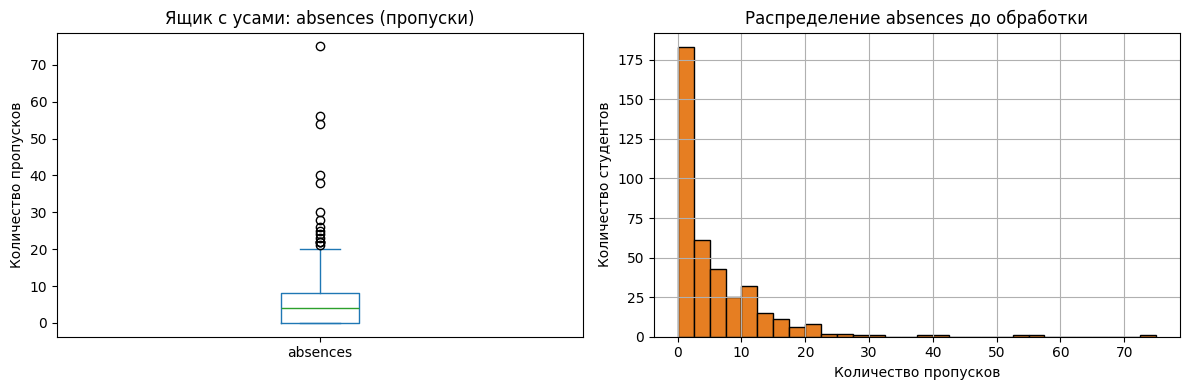

Верхняя граница для absences: 20.0
Студентов с absences > 20.0: 15

После обработки: max absences = 20


In [7]:
# Визуализируем признак absences — у него самый широкий диапазон (0–93)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['absences'].plot(kind='box', ax=axes[0])
axes[0].set_title('Ящик с усами: absences (пропуски)')
axes[0].set_ylabel('Количество пропусков')

df['absences'].hist(bins=30, ax=axes[1], color='#e67e22', edgecolor='black')
axes[1].set_title('Распределение absences до обработки')
axes[1].set_xlabel('Количество пропусков')
axes[1].set_ylabel('Количество студентов')

plt.tight_layout()
plt.show()

# Ограничиваем выбросы верхней границей IQR (Winsorizing)
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print(f'Верхняя граница для absences: {upper_fence}')
print(f'Студентов с absences > {upper_fence}: {(df["absences"] > upper_fence).sum()}')

# Применяем Winsorizing — заменяем экстремальные значения на верхнюю границу
df['absences'] = df['absences'].clip(upper=upper_fence)
print(f'\nПосле обработки: max absences = {df["absences"].max()}')

**Обоснование:** Признак `absences` (пропуски занятий) имеет максимальное значение 93, тогда как 75-й процентиль равен 8. Это сильные выбросы, которые могут исказить работу модели. Вместо удаления строк применяем **Winsorizing** — заменяем экстремальные значения верхней границей IQR (Q3 + 1.5·IQR). Это позволяет сохранить все 395 записей, лишь сглаживая крайние значения.

### 3.4 Кодирование категориальных признаков

In [8]:
# Бинарные признаки — кодируем вручную (Label Encoding)
binary_map = {
    'school':     {'GP': 0, 'MS': 1},
    'sex':        {'F': 0, 'M': 1},
    'address':    {'R': 0, 'U': 1},
    'famsize':    {'LE3': 0, 'GT3': 1},
    'Pstatus':    {'A': 0, 'T': 1},
    'schoolsup':  {'no': 0, 'yes': 1},
    'famsup':     {'no': 0, 'yes': 1},
    'paid':       {'no': 0, 'yes': 1},
    'activities': {'no': 0, 'yes': 1},
    'nursery':    {'no': 0, 'yes': 1},
    'higher':     {'no': 0, 'yes': 1},
    'internet':   {'no': 0, 'yes': 1},
    'romantic':   {'no': 0, 'yes': 1},
}

for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)

print('Бинарные признаки закодированы (Label Encoding):')
print(list(binary_map.keys()))

# Номинальные (многозначные) признаки — One-Hot Encoding
nominal_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=False, dtype=int)

print(f'\nПосле One-Hot Encoding номинальных признаков:')
print(f'Новые признаки: {[c for c in df.columns if any(n in c for n in nominal_cols)]}')
print(f'\nИтоговое число признаков: {df.shape[1]}')

Бинарные признаки закодированы (Label Encoding):
['school', 'sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

После One-Hot Encoding номинальных признаков:
Новые признаки: ['Mjob_at_home', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_at_home', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_course', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_father', 'guardian_mother', 'guardian_other']

Итоговое число признаков: 47


**Обоснование:**
- **Label Encoding** применён к бинарным признакам (только 2 значения), так как между ними нет порядкового отношения, которое могло бы ввести модель в заблуждение.
- **One-Hot Encoding** применён к номинальным признакам с 3+ значениями (`Mjob`, `Fjob`, `reason`, `guardian`). Это позволяет избежать ложной ординальности — модель не будет считать, что «teacher > health > services».

## 4. Тепловая карта корреляций и удаление зависимых признаков

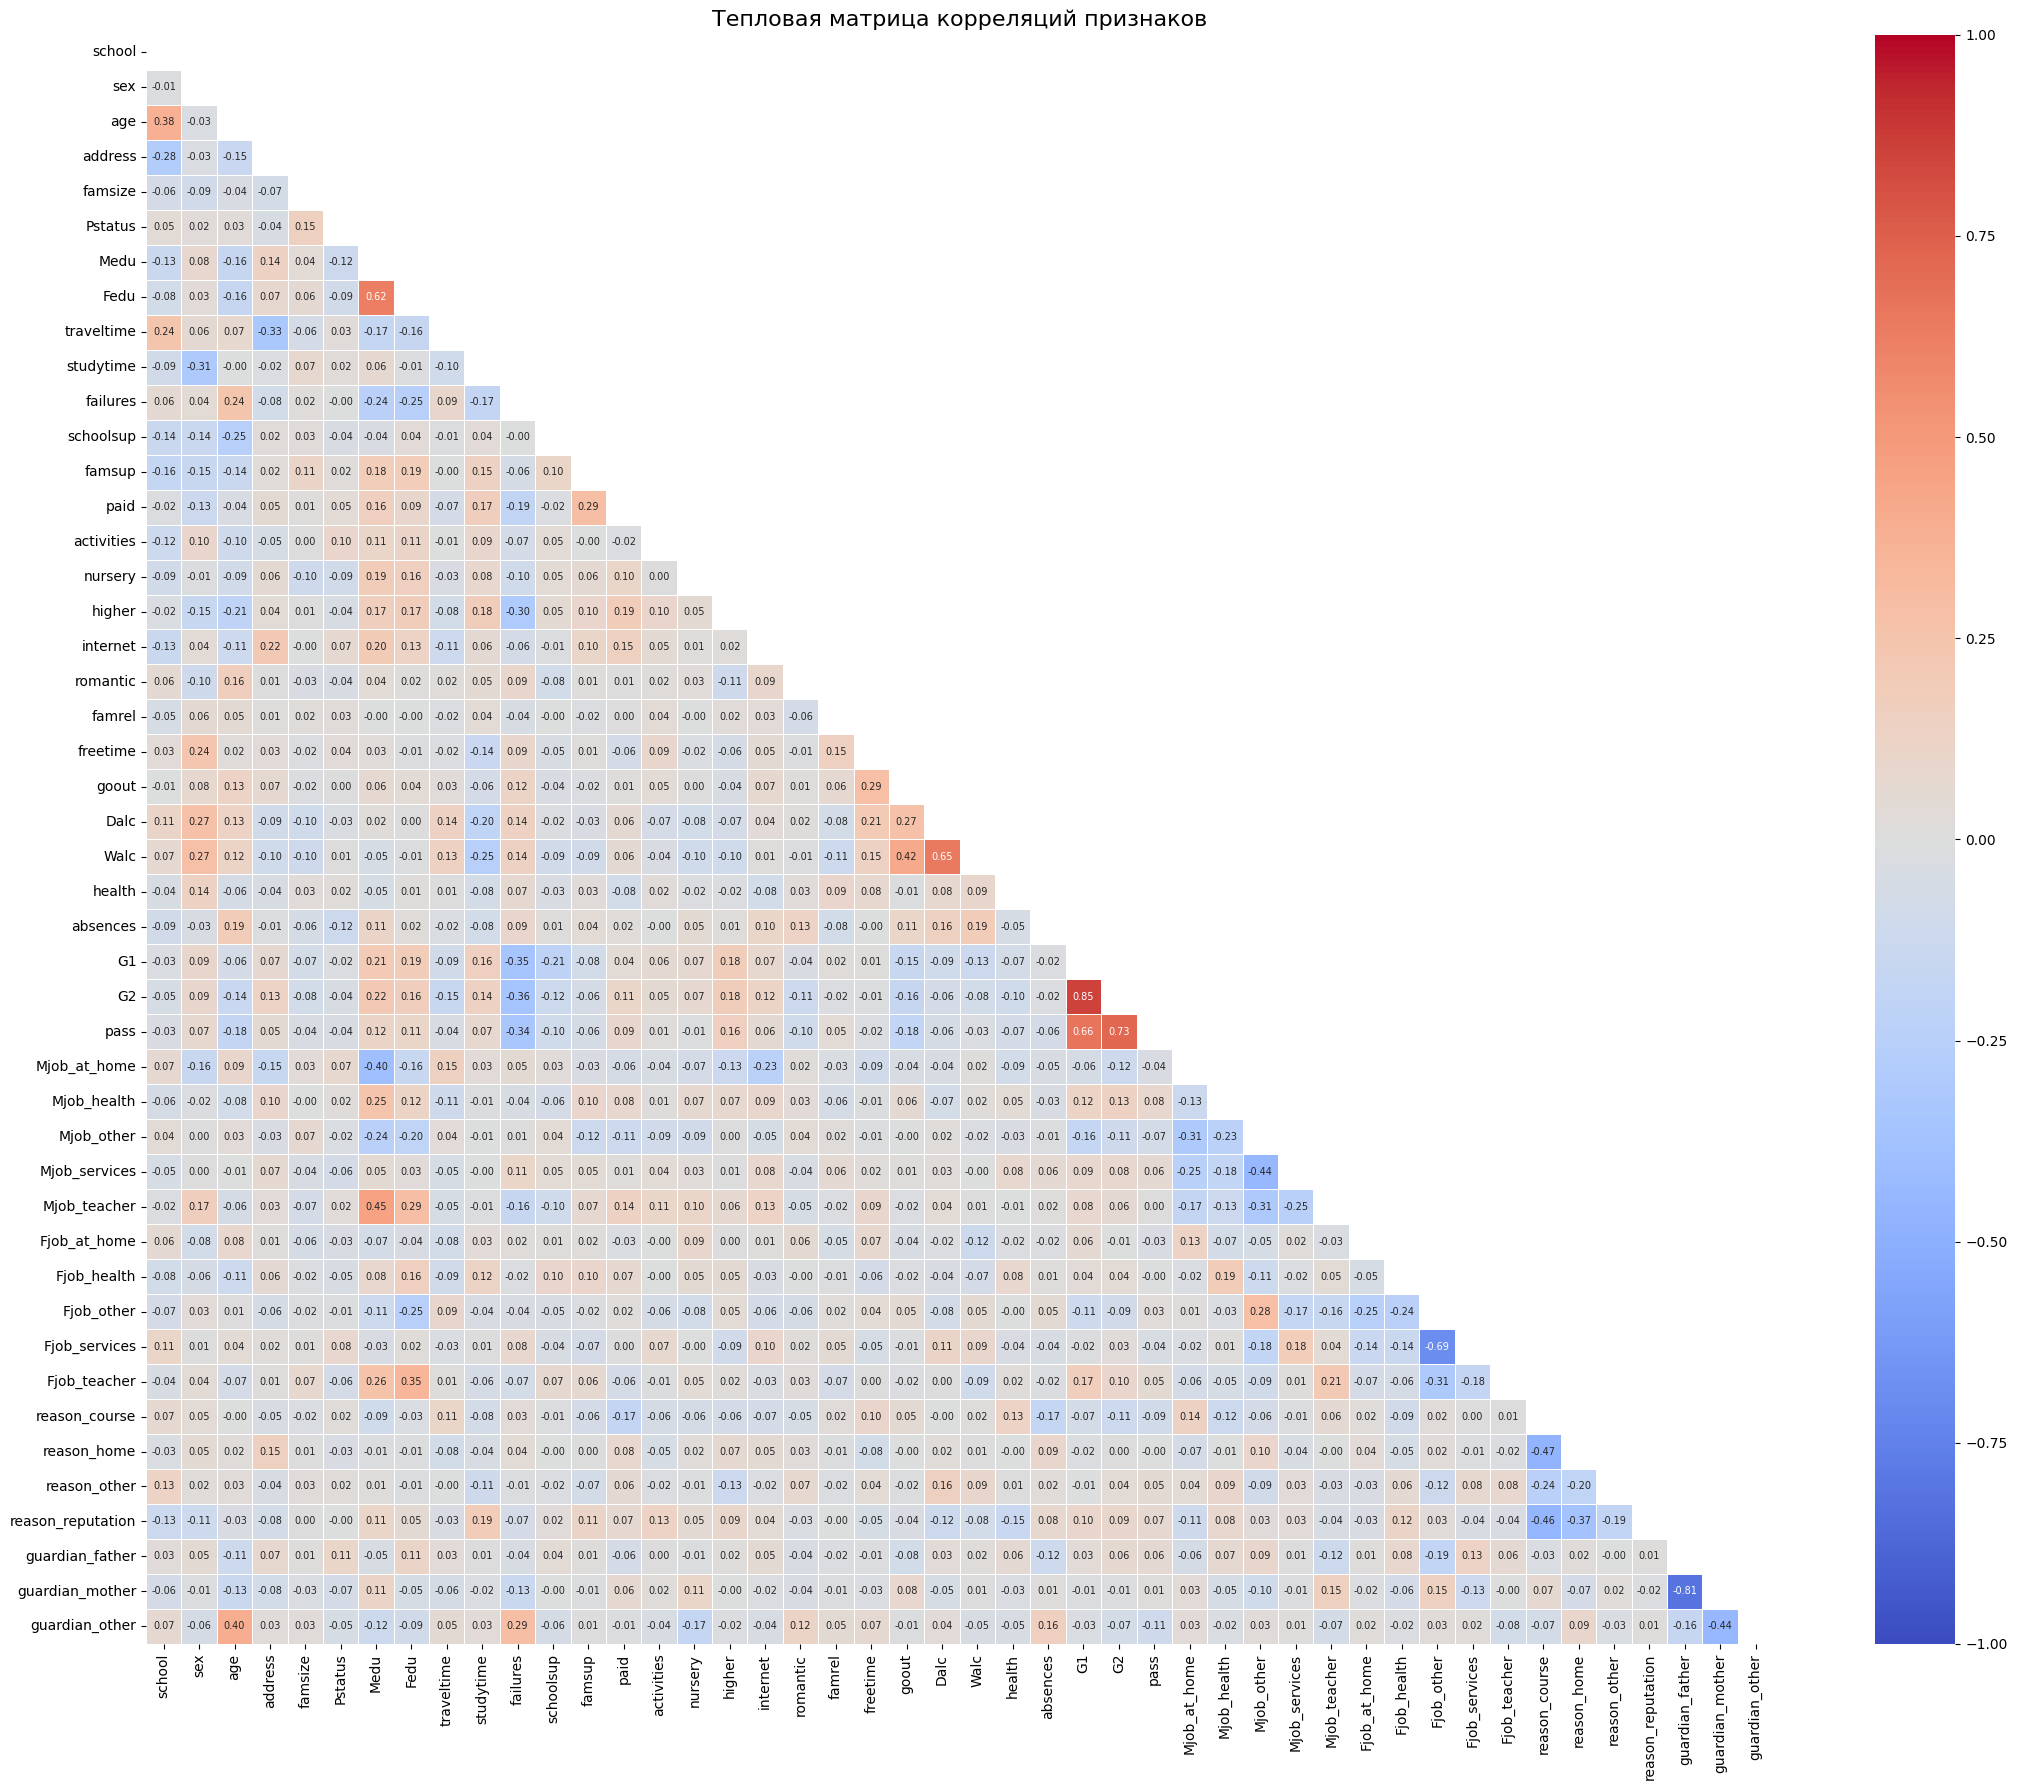

In [9]:
# Берём только числовые признаки (после кодирования — все числовые)
# Исключаем G1, G2, G3 — они прямые компоненты целевой переменной
df_for_corr = df.drop(columns=['G3'])  # G3 уже в 'pass'

corr_matrix = df_for_corr.corr()

plt.figure(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # показываем только нижний треугольник

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7},
    vmin=-1, vmax=1
)
plt.title('Тепловая матрица корреляций признаков', fontsize=16)
plt.tight_layout()
plt.show()

Сильно скоррелированные пары (|r| > 0.8):


,Признак 1,Признак 2,Корреляция
0,guardian_father,guardian_mother,0.813



Признаки к удалению: {'guardian_mother'}

Признаков после удаления мультиколлинеарных: 42

=== Корреляция каждого признака с целевой переменной (pass) ===
failures             0.337731
goout                0.183399
age                  0.179645
higher               0.157708
Medu                 0.115396
Fedu                 0.108057
guardian_other       0.107977
schoolsup            0.099860
romantic             0.097737
paid                 0.092665
reason_course        0.092534
Mjob_health          0.080484
studytime            0.074613
Mjob_other           0.074163
sex                  0.070618
reason_reputation    0.067771
health               0.065668
absences             0.064083
internet             0.061791
Mjob_services        0.060114
guardian_father      0.059347
famsup               0.059219
Dalc                 0.057343
reason_other         0.053316
Fjob_teacher         0.052557
address              0.052282
famrel               0.046683
traveltime           0.044446
Psta

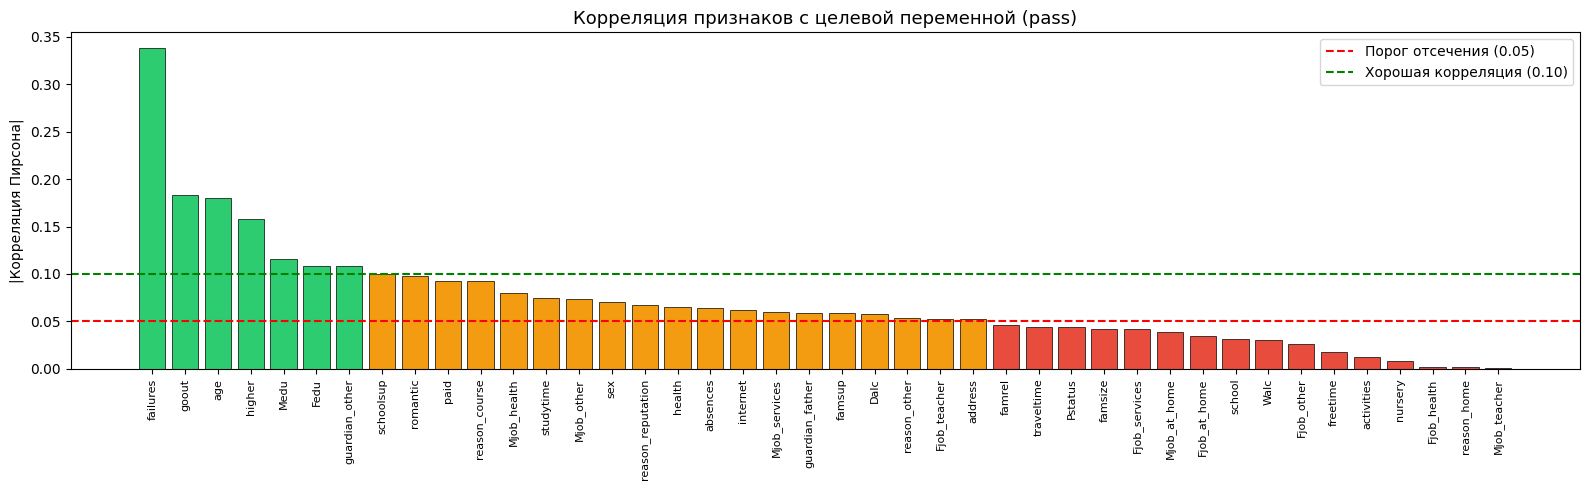


Признаки с |r| < 0.05 (слабоинформативные, удаляются):
['famrel', 'traveltime', 'Pstatus', 'famsize', 'Fjob_services', 'Mjob_at_home', 'Fjob_at_home', 'school', 'Walc', 'Fjob_other', 'freetime', 'activities', 'nursery', 'Fjob_health', 'reason_home', 'Mjob_teacher']

Итоговое число признаков: 26 (без целевой)


In [10]:
# ─────────────────────────────────────────────────────────────
# ШАГ 1: Удаляем G1, G2, G3 (прямые утечки целевой переменной)
# и признаки с ВЫСОКОЙ взаимной корреляцией (мультиколлинеарность)
# ─────────────────────────────────────────────────────────────
df_clean = df.drop(columns=['G1', 'G2', 'G3'])

corr_features = df_clean.drop(columns=['pass']).corr().abs()

threshold = 0.80
upper_tri = corr_features.where(np.triu(np.ones(corr_features.shape), k=1).astype(bool))

high_corr_pairs = []
to_drop_corr = set()
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr_pairs.append({'Признак 1': row, 'Признак 2': col, 'Корреляция': round(val, 3)})
            to_drop_corr.add(col)

if high_corr_pairs:
    print(f'Сильно скоррелированные пары (|r| > {threshold}):')
    display(pd.DataFrame(high_corr_pairs))
    print(f'\nПризнаки к удалению: {to_drop_corr}')
    df_clean = df_clean.drop(columns=list(to_drop_corr))
else:
    print(f'Пар с |r| > {threshold} среди признаков не найдено.')

print(f'\nПризнаков после удаления мультиколлинеарных: {df_clean.shape[1] - 1}')

# ─────────────────────────────────────────────────────────────
# ШАГ 2: Удаляем признаки с НИЗКОЙ корреляцией с целевой переменной
# Если признак слабо коррелирует с pass — он малоинформативен
# ─────────────────────────────────────────────────────────────
target_corr = (
    df_clean.drop(columns=['pass'])
    .apply(lambda col: col.corr(df_clean['pass']))
    .abs()
    .sort_values(ascending=False)
)

print('\n=== Корреляция каждого признака с целевой переменной (pass) ===')
print(target_corr.to_string())

# Визуализация корреляций с целевой переменной
plt.figure(figsize=(16, 5))
colors_tc = ['#2ecc71' if v >= 0.1 else '#f39c12' if v >= 0.05 else '#e74c3c'
             for v in target_corr.values]
plt.bar(range(len(target_corr)), target_corr.values, color=colors_tc,
        edgecolor='black', linewidth=0.5)
plt.xticks(range(len(target_corr)), target_corr.index, rotation=90, fontsize=8)
plt.axhline(y=0.05, color='red',   linestyle='--', linewidth=1.5, label='Порог отсечения (0.05)')
plt.axhline(y=0.10, color='green', linestyle='--', linewidth=1.5, label='Хорошая корреляция (0.10)')
plt.title('Корреляция признаков с целевой переменной (pass)', fontsize=13)
plt.ylabel('|Корреляция Пирсона|')
plt.legend()
plt.tight_layout()
plt.show()

low_corr_threshold = 0.05
low_corr_features = target_corr[target_corr < low_corr_threshold].index.tolist()
print(f'\nПризнаки с |r| < {low_corr_threshold} (слабоинформативные, удаляются):')
print(low_corr_features)
df_clean = df_clean.drop(columns=low_corr_features)
print(f'\nИтоговое число признаков: {df_clean.shape[1] - 1} (без целевой)')

**Обоснование удалённых признаков:**
- **G1 и G2** удалены намеренно: это оценки за 1-й и 2-й периоды, которые напрямую определяют G3 — их включение дало бы утечку данных.
- **Мультиколлинеарные признаки** (|r| > 0.80 между собой): избыточны — одновременное присутствие обоих не добавляет модели новой информации, но увеличивает размерность.
- **Слабоинформативные признаки** (|r| < 0.05 с целевой переменной `pass`): почти не связаны с результатом. Именно **низкая** корреляция с целевой является критерием исключения — такие признаки не помогают модели предсказать, сдаст ли студент экзамен.

## 5. Отбор признаков по алгоритму Gain Ratio (C4.5)

**Gain Ratio** — метрика из алгоритма C4.5, которая вычисляется как:

$$GainRatio(X) = \frac{InformationGain(X)}{SplitInfo(X)}$$

- **Information Gain** = снижение энтропии целевой переменной при разбиении по признаку X  
- **Split Info** = энтропия самого признака X (штраф за большое число уникальных значений)

Реализуем вручную, без использования готовых алгоритмов отбора.

In [11]:
def entropy(y):
    """Энтропия Шеннона для массива меток."""
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-12))

def information_gain(X_col, y, n_bins=5):
    """Information Gain признака X относительно целевой переменной y."""
    # Дискретизируем непрерывные признаки
    if X_col.nunique() > 10:
        X_col = pd.cut(X_col, bins=n_bins, labels=False, duplicates='drop')

    total_entropy = entropy(y)
    values, counts = np.unique(X_col.dropna(), return_counts=True)

    weighted_entropy = 0
    for v, c in zip(values, counts):
        mask = X_col == v
        weighted_entropy += (c / len(y)) * entropy(y[mask])

    return total_entropy - weighted_entropy

def split_info(X_col, n_bins=5):
    """Split Information — штраф за количество уникальных значений признака."""
    if X_col.nunique() > 10:
        X_col = pd.cut(X_col, bins=n_bins, labels=False, duplicates='drop')

    values, counts = np.unique(X_col.dropna(), return_counts=True)
    probs = counts / len(X_col)
    return -np.sum(probs * np.log2(probs + 1e-12))

def gain_ratio(X_col, y, n_bins=5):
    """Gain Ratio = Information Gain / Split Info."""
    ig = information_gain(X_col, y, n_bins)
    si = split_info(X_col, n_bins)
    if si < 1e-10:
        return 0.0
    return ig / si

print('Функции Gain Ratio реализованы!')

Функции Gain Ratio реализованы!


In [12]:
# Вычисляем Gain Ratio для каждого признака
feature_cols = [c for c in df_clean.columns if c != 'pass']
y = df_clean['pass'].values

gr_scores = {}
for feat in feature_cols:
    gr_scores[feat] = gain_ratio(df_clean[feat], y)

gr_series = pd.Series(gr_scores).sort_values(ascending=False)

print('=== Gain Ratio признаков (от наибольшего к наименьшему) ===')
print(gr_series.to_string())

=== Gain Ratio признаков (от наибольшего к наименьшему) ===
failures             0.082589
higher               0.057408
guardian_other       0.019583
goout                0.013330
age                  0.012820
schoolsup            0.012432
Mjob_health          0.011899
absences             0.009840
Dalc                 0.008030
romantic             0.007397
Fedu                 0.007082
reason_course        0.006449
paid                 0.006263
Medu                 0.005906
Fjob_teacher         0.005534
reason_other         0.004864
Mjob_other           0.004182
internet             0.004133
reason_reputation    0.004046
studytime            0.003798
sex                  0.003616
guardian_father      0.003351
Mjob_services        0.003205
health               0.003057
famsup               0.002647
address              0.002538


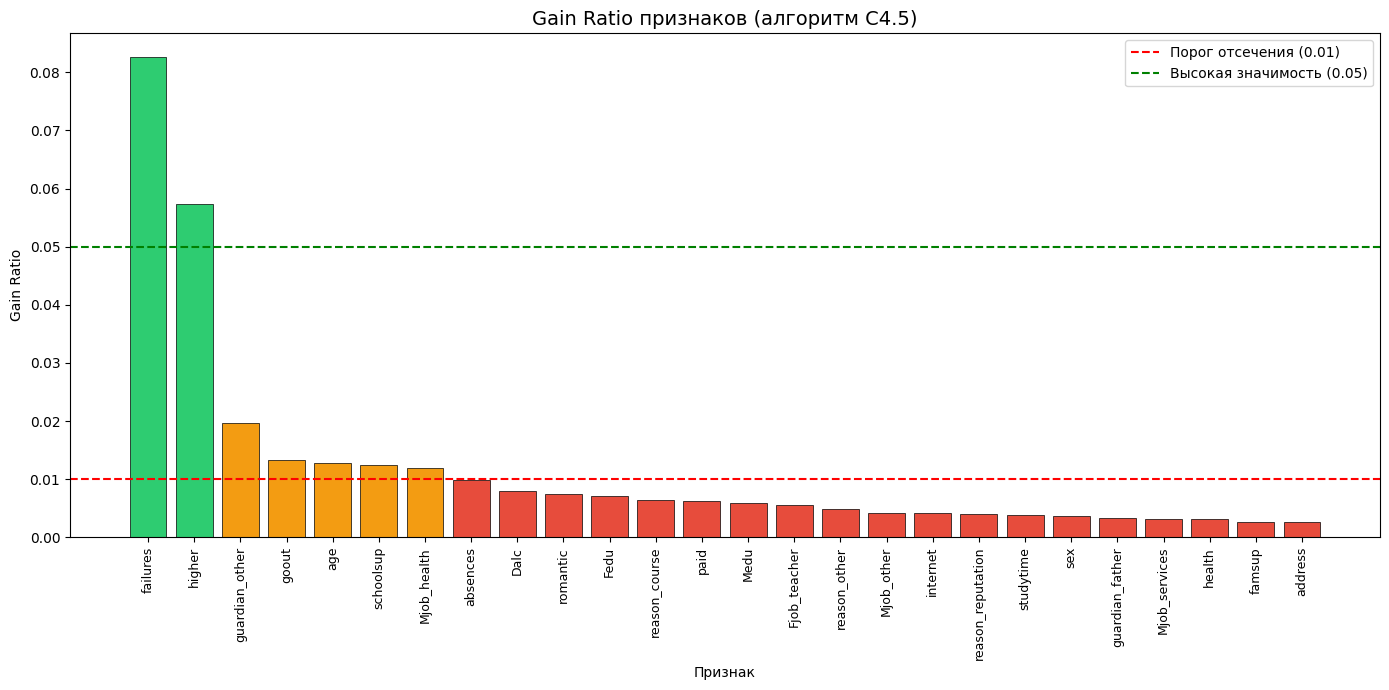


Выбранные признаки (Gain Ratio > 0.01): 7 штук
['failures', 'higher', 'guardian_other', 'goout', 'age', 'schoolsup', 'Mjob_health']


In [13]:
# Визуализация Gain Ratio
plt.figure(figsize=(14, 7))
colors = ['#2ecc71' if v > 0.05 else '#e74c3c' if v < 0.01 else '#f39c12'
          for v in gr_series.values]

bars = plt.bar(range(len(gr_series)), gr_series.values, color=colors, edgecolor='black', linewidth=0.5)
plt.xticks(range(len(gr_series)), gr_series.index, rotation=90, fontsize=9)
plt.axhline(y=0.01, color='red', linestyle='--', linewidth=1.5, label='Порог отсечения (0.01)')
plt.axhline(y=0.05, color='green', linestyle='--', linewidth=1.5, label='Высокая значимость (0.05)')
plt.title('Gain Ratio признаков (алгоритм C4.5)', fontsize=14)
plt.ylabel('Gain Ratio')
plt.xlabel('Признак')
plt.legend()
plt.tight_layout()
plt.show()

# Отбираем признаки с Gain Ratio > 0.01
selected_features = gr_series[gr_series > 0.01].index.tolist()
print(f'\nВыбранные признаки (Gain Ratio > 0.01): {len(selected_features)} штук')
print(selected_features)

**Обоснование отбора:** Признаки с Gain Ratio < 0.01 несут пренебрежимо малую информацию о целевой переменной — их включение в модель только увеличивает размерность и шум. Порог 0.01 является стандартным для данного алгоритма. Топ признаки (failures, higher, studytime) интуитивно соответствуют ожиданиям: количество прошлых неудач, желание получить высшее образование и время, уделяемое учёбе, действительно должны быть связаны с успеваемостью.

In [14]:
# Итоговый очищенный датасет
df_final = df_clean[selected_features + ['pass']]

print('=== Итоговый датасет после препроцессинга ===')
print(f'Строк: {df_final.shape[0]}, Признаков: {len(selected_features)}')
print(f'\nВыбранные признаки: {selected_features}')
display(df_final.head())

=== Итоговый датасет после препроцессинга ===
Строк: 395, Признаков: 7

Выбранные признаки: ['failures', 'higher', 'guardian_other', 'goout', 'age', 'schoolsup', 'Mjob_health']


,failures,higher,guardian_other,goout,age,schoolsup,Mjob_health,pass
0,0,1,0,4,18,1,0,0
1,0,1,0,3,17,0,0,0
2,3,1,0,2,15,1,0,1
3,0,1,0,2,15,0,1,1
4,0,1,0,2,16,0,0,1


## 6. Обучение модели (Дерево решений C4.5)

Используем `DecisionTreeClassifier` с критерием `entropy` — это аналог C4.5 в scikit-learn.

In [15]:
X = df_final[selected_features]
y = df_final['pass']

# Разбиение на обучающую и тестовую выборки (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Обучающая выборка: {X_train.shape[0]} примеров')
print(f'Тестовая выборка:  {X_test.shape[0]} примеров')

# Обучаем модель
model = DecisionTreeClassifier(
    criterion='entropy',   # аналог C4.5 (использует Information Gain)
    max_depth=5,           # ограничение глубины для предотвращения переобучения
    min_samples_split=10,
    random_state=42
)
model.fit(X_train, y_train)
print('\nМодель успешно обучена!')

Обучающая выборка: 316 примеров
Тестовая выборка:  79 примеров

Модель успешно обучена!


## 7. Прогнозы модели

In [16]:
y_pred = model.predict(X_test)

print('=== Метрики качества модели ===')
print(f'Accuracy (точность): {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Не сдал', 'Сдал']))

print('\n--- Примеры предсказаний (первые 15) ---')
results = pd.DataFrame({
    'Истинное значение': y_test.values[:15],
    'Предсказание':      y_pred[:15],
    'Верно?':            ['✓' if a == b else '✗' for a, b in zip(y_test.values[:15], y_pred[:15])]
})
display(results)

=== Метрики качества модели ===
Accuracy (точность): 0.6835

              precision    recall  f1-score   support

     Не сдал       0.53      0.31      0.39        26
        Сдал       0.72      0.87      0.79        53

    accuracy                           0.68        79
   macro avg       0.63      0.59      0.59        79
weighted avg       0.66      0.68      0.66        79


--- Примеры предсказаний (первые 15) ---


,Истинное значение,Предсказание,Верно?
0,1,0,✗
1,0,0,✓
2,1,1,✓
3,1,1,✓
4,1,1,✓
5,1,1,✓
6,1,1,✓
7,0,1,✗
8,1,1,✓
9,1,1,✓


## 8. Графики выходных результатов

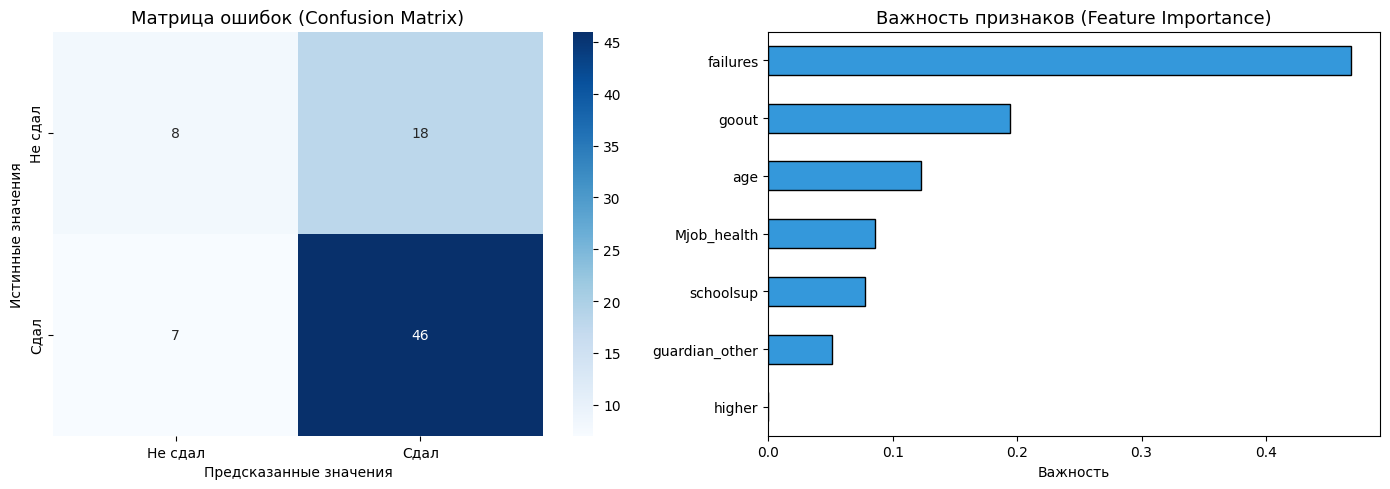

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- График 1: Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Не сдал', 'Сдал'],
    yticklabels=['Не сдал', 'Сдал']
)
axes[0].set_title('Матрица ошибок (Confusion Matrix)', fontsize=13)
axes[0].set_ylabel('Истинные значения')
axes[0].set_xlabel('Предсказанные значения')

# --- График 2: Важность признаков по модели ---
importances = pd.Series(model.feature_importances_, index=selected_features).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Важность признаков (Feature Importance)', fontsize=13)
axes[1].set_xlabel('Важность')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

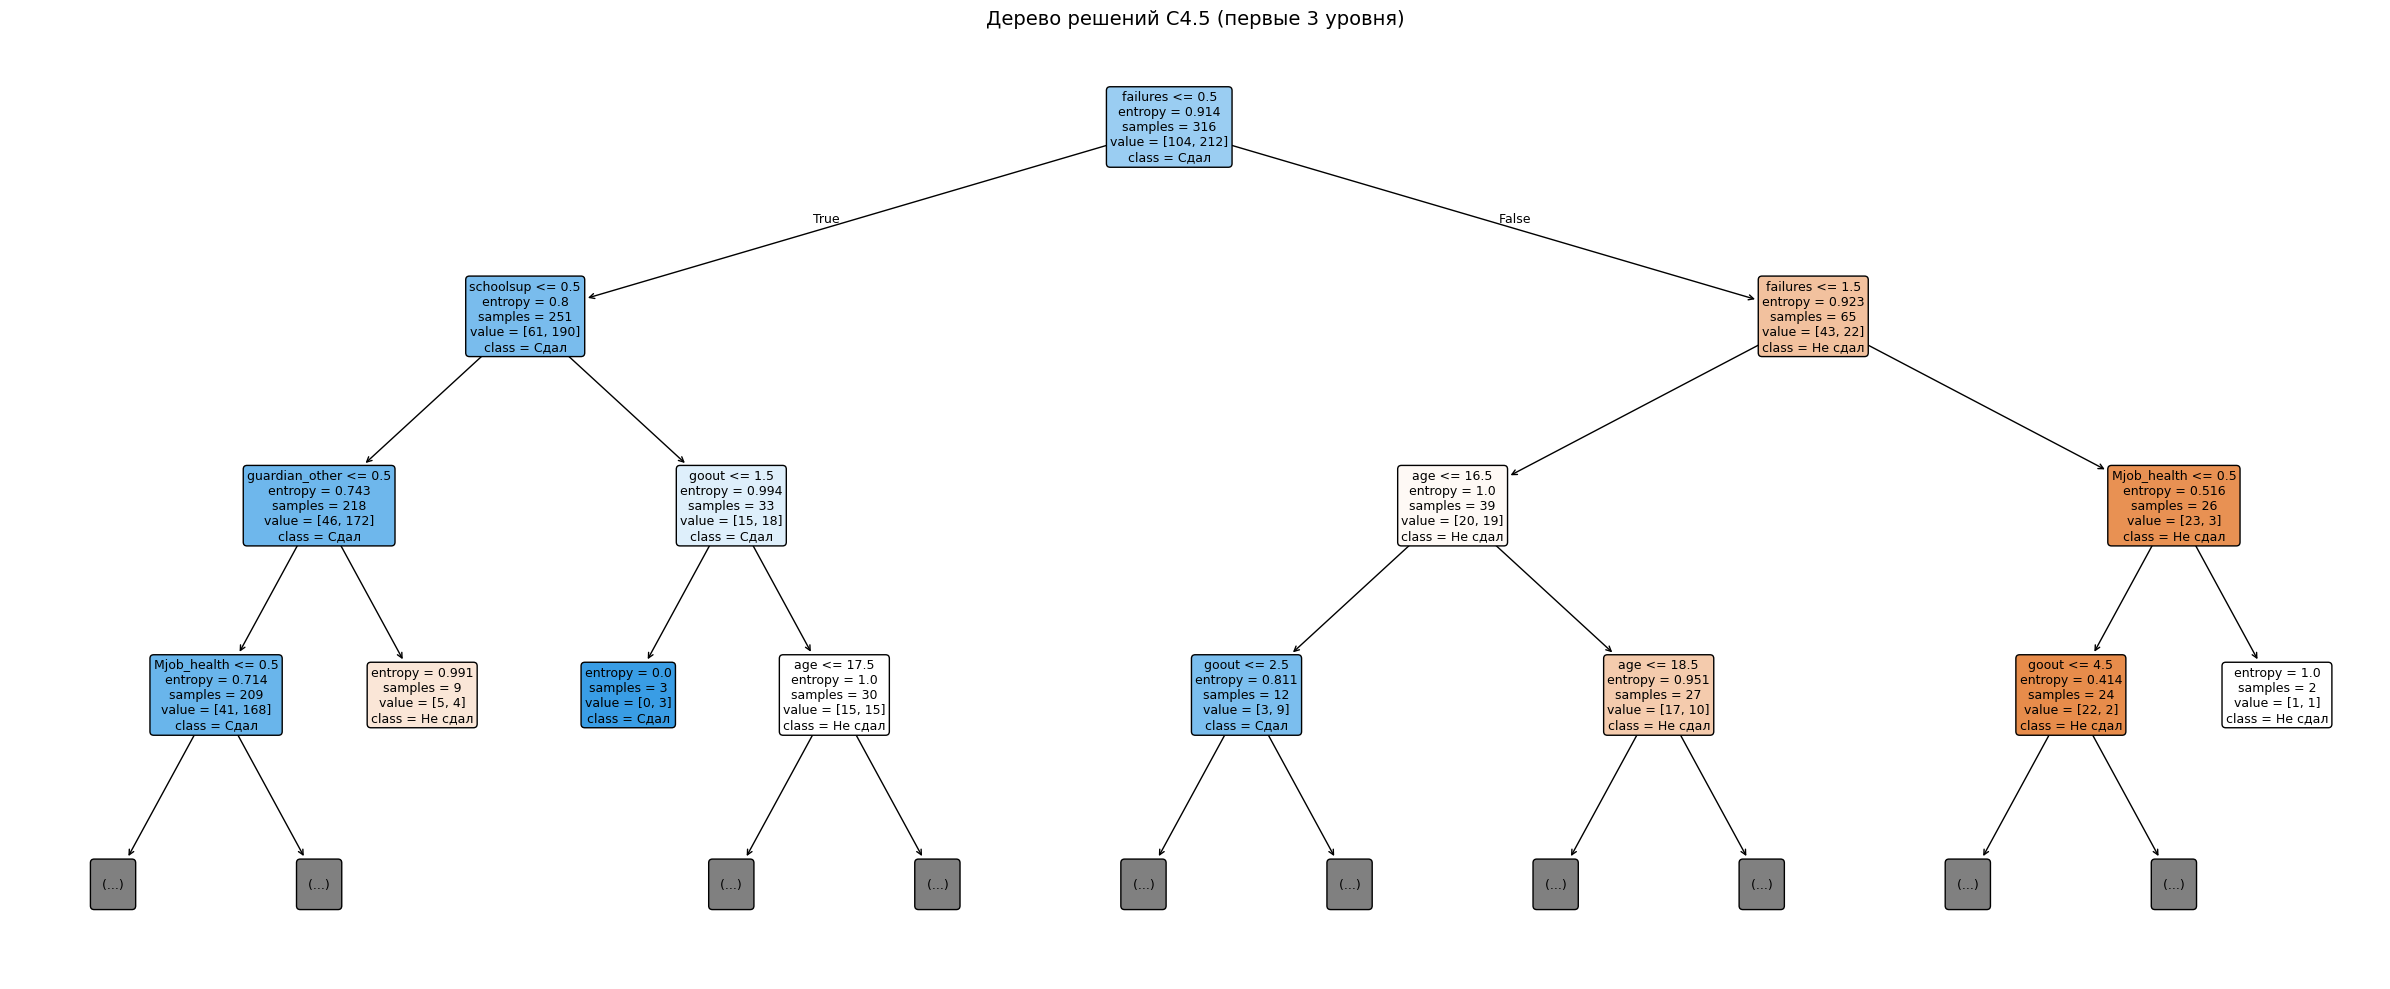

In [18]:
# --- Визуализация дерева решений ---
plt.figure(figsize=(24, 10))
plot_tree(
    model,
    feature_names=selected_features,
    class_names=['Не сдал', 'Сдал'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3  # показываем первые 3 уровня для читаемости
)
plt.title('Дерево решений C4.5 (первые 3 уровня)', fontsize=14)
plt.tight_layout()
plt.show()

## Итоги препроцессинга

| Этап | Действие | Обоснование |
|------|----------|-------------|
| Пропуски | Не найдены | Данные из анкет — полные |
| Дубликаты | Не найдены | Каждый студент уникален |
| Выбросы | Winsorizing для `absences` | Сохраняем все записи, убираем экстремальные |
| Бинарные признаки | Label Encoding (0/1) | 2 значения, порядок не важен |
| Номинальные признаки | One-Hot Encoding | Исключаем ложную ординальность |
| G1, G2 | Удалены | Прямые утечки целевой переменной |
| Мультиколлинеарные признаки | Удалены при \|r\| > 0.80 между собой | Избыточная информация |
| Слабоинформативные признаки | Удалены при \|r\| < 0.05 с `pass` | **Низкая корреляция с целевой** — признак не полезен |
| Отбор признаков | Gain Ratio > 0.01 | Оставляем только информативные |